# Кластеризация v4 — поведенческие признаки без сезонных pct_*

**История исправлений:**

| Версия | Признаков | k | Проблема |
|---|---|---|---|
| v1 | 29 (с tariff/room) | 4 | ARI(кластеры, tariff)=0.88 — ML переоткрывал тарифы |
| v2 | 14 (с gender OHE) | 5 | 97% dist(C0,C1) = gender; кластеры по полу |
| v3 | 10 (без gender/age_is_unknown) | 5 | pct_summer/autumn/winter → кластеры по сезону заезда |
| **v4** | **8 (чисто поведенческие)** | **?** | **—** |

**Изменения по сравнению с v3:**
- Убраны `pct_summer`, `pct_autumn`, `pct_winter` → перенесены в матрицу аффинности (Шаг 6)
- Убраны `discount_rate`, `booking_group_size` → дублировали тарифную группу
- Отфильтрованы ФСС/корпоративные гости → не реагируют на офферы
- Добавлены `is_treatment` (мотивация) и `price_tier` (бюджет)
- Возвращён `pct_weekend_in` (паттерн рабочей недели)

**Данные:** `artifacts/df_for_model_cluster.parquet`

In [1]:
import numpy as np
import pandas as pd
import joblib
import pathlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score,
)
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE      = 42
K_MIN, K_MAX      = 2, 10
KMEANS_N_INIT     = 10
KMEANS_N_INIT_FIN = 20
SILHOUETTE_SAMPLE = 50_000
PS_N_SPLITS       = 5

ARTIFACTS_IN = pathlib.Path('artifacts')
ARTIFACTS_V4 = pathlib.Path('artifacts_v4')
ARTIFACTS_V4.mkdir(exist_ok=True)

# False: если артефакты уже есть — загрузить, не пересчитывать.
# True: принудительно переобучить и перезаписать все артефакты.
FORCE_REFIT = True

print('Импорты OK')

Импорты OK


## Шаг 1 — Признаки и загрузка данных

| Признак | Тип | Трансформация | Обоснование |
|---|---|---|---|
| stay_duration | num | log1p → StandardScaler | Длительность заезда |
| lead_time | num | уже log1p → StandardScaler | Горизонт бронирования |
| guest_age | num | StandardScaler | Возраст |
| prev_stays | num | уже log1p → StandardScaler | Лояльность из CRM |
| pct_weekend_in | num | StandardScaler | Паттерн дня заезда |
| price_tier | num | StandardScaler | Бюджет: ЛАЙТ=1, ОПТИМА=2, УЛЬТРА=3 |
| has_children | bin | StandardScaler | Семейный гость |
| is_treatment | bin | StandardScaler | Мотивация: оздоровление vs отдых |

**Не входят в модель:** `pct_summer`, `pct_autumn`, `pct_winter`, `pct_spring` (матрица аффинности),  
`tariff_group`, `room_group`, `gender` (профилирование и ARI-проверка)

In [2]:
LOG1P_ALREADY = ['lead_time', 'prev_stays']
NEEDS_LOG1P   = ['stay_duration']
PLAIN_NUM     = ['guest_age', 'pct_weekend_in', 'price_tier']
BIN_COLS      = ['has_children', 'is_treatment']
ALL_FEATURES  = LOG1P_ALREADY + NEEDS_LOG1P + PLAIN_NUM + BIN_COLS

df = pd.read_parquet(ARTIFACTS_IN / 'df_for_model_cluster.parquet')
print(f'df: {df.shape[0]:,} гостей x {df.shape[1]} колонок')
print(f'Признаков в модели: {len(ALL_FEATURES)}')
print(f'Пропуски: {df[ALL_FEATURES].isnull().sum().sum()} (должно быть 0)')
print(f'\nprice_tier: {df["price_tier"].value_counts().sort_index().to_dict()}')
print(f'is_treatment: {df["is_treatment"].mean()*100:.1f}% гостей')

df[ALL_FEATURES].describe().round(3)


df: 248,547 гостей x 18 колонок
Признаков в модели: 8
Пропуски: 0 (должно быть 0)

price_tier: {1: 75596, 2: 73402, 3: 99549}
is_treatment: 6.7% гостей


,lead_time,prev_stays,stay_duration,guest_age,pct_weekend_in,price_tier,has_children,is_treatment
count,248547.000,248547.000,248547.000,248547.000,248547.000,248547.000,248547.000,248547.000
mean,3.605,0.568,5.989,32.900,0.313,2.096,0.388,0.067
std,1.254,0.537,4.148,16.352,0.457,0.834,0.487,0.249
min,0.000,0.000,1.000,1.000,0.000,1.000,0.000,0.000
25%,2.890,0.000,3.000,16.000,0.000,1.000,0.000,0.000
50%,3.784,0.693,5.000,37.000,0.000,2.000,0.000,0.000
75%,4.543,0.693,8.000,40.000,1.000,3.000,1.000,0.000
max,6.537,6.475,89.000,97.000,1.000,3.000,1.000,1.000


## Шаг 2 — Препроцессор

- `already_log1p` → StandardScaler (log1p уже применён в `pipeline_clustering.ipynb`)  
- `needs_log1p` → FunctionTransformer(log1p) → StandardScaler  
- `plain_num` → StandardScaler  
- `binary` → StandardScaler (std≈1, равный вес с числовыми)  

Нет OHE-блока: категориальные признаки исключены из модели.

In [3]:
def _log1p_clip(X):
    """log1p с clip(0) — совместимо с joblib.dump (именованная функция)."""
    return np.log1p(np.clip(X, 0, None))

_X_path = ARTIFACTS_V4 / 'X_scaled_v4.npy'

if FORCE_REFIT or not _X_path.exists():
    log1p_tf = FunctionTransformer(func=_log1p_clip, validate=False)

    preprocessor_v4 = ColumnTransformer([
        ('already_log1p', StandardScaler(), LOG1P_ALREADY),
        ('needs_log1p',   Pipeline([('log1p', log1p_tf), ('scaler', StandardScaler())]), NEEDS_LOG1P),
        ('plain_num',     StandardScaler(), PLAIN_NUM),
        ('binary',        StandardScaler(), BIN_COLS),
    ], remainder='drop')

    X_v4 = preprocessor_v4.fit_transform(df[ALL_FEATURES]).astype(np.float32)
    feature_names_v4 = LOG1P_ALREADY + NEEDS_LOG1P + PLAIN_NUM + BIN_COLS

    print(f'X_scaled_v4: {X_v4.shape}  dtype={X_v4.dtype}')
    print(f'NaN: {np.isnan(X_v4).sum()} (должно быть 0)')
    X_df_v4 = pd.DataFrame(X_v4, columns=feature_names_v4)
    print('\nСтандартные отклонения (все должны быть ~1.0):')
    print(X_df_v4.std().round(4).to_string())

    np.save(_X_path, X_v4)
    joblib.dump(preprocessor_v4, ARTIFACTS_V4 / 'preprocessor_v4.joblib')
    joblib.dump({
        'feature_names_out': feature_names_v4,
        'LOG1P_ALREADY': LOG1P_ALREADY, 'NEEDS_LOG1P': NEEDS_LOG1P,
        'PLAIN_NUM': PLAIN_NUM, 'BIN_COLS': BIN_COLS, 'ALL_FEATURES': ALL_FEATURES,
    }, ARTIFACTS_V4 / 'feature_meta_v4.joblib')
    print('\nСохранено: X_scaled_v4.npy, preprocessor_v4.joblib, feature_meta_v4.joblib')
else:
    X_v4 = np.load(_X_path)
    preprocessor_v4  = joblib.load(ARTIFACTS_V4 / 'preprocessor_v4.joblib')
    feature_names_v4 = joblib.load(ARTIFACTS_V4 / 'feature_meta_v4.joblib')['feature_names_out']
    print(f'Загружено из кэша: X_scaled_v4 {X_v4.shape}  (FORCE_REFIT=False)')


X_scaled_v4: (248547, 8)  dtype=float32
NaN: 0 (должно быть 0)

Стандартные отклонения (все должны быть ~1.0):
lead_time         1.0000
prev_stays        0.9996
stay_duration     0.9999
guest_age         1.0001
pct_weekend_in    1.0003
price_tier        0.9999
has_children      1.0011
is_treatment      1.0009

Сохранено: X_scaled_v4.npy, preprocessor_v4.joblib, feature_meta_v4.joblib


## Шаг 3 — Метрики для k=2..9

In [4]:
inertia_v4 = []; silhouette_v4 = []; calinski_v4 = []; davies_v4 = []
rng_sil = np.random.RandomState(RANDOM_STATE)

for k in range(K_MIN, K_MAX):
    km = KMeans(n_clusters=k, init='k-means++',
                n_init=KMEANS_N_INIT, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_v4)
    inertia_v4.append(km.inertia_)

    idx = rng_sil.choice(len(X_v4), SILHOUETTE_SAMPLE, replace=False)
    sil = silhouette_score(X_v4[idx], labels[idx], random_state=RANDOM_STATE)
    silhouette_v4.append(sil)
    calinski_v4.append(calinski_harabasz_score(X_v4, labels))
    davies_v4.append(davies_bouldin_score(X_v4, labels))
    print(f'k={k}: inertia={km.inertia_:,.0f}  sil={sil:.4f}  '
          f'CH={calinski_v4[-1]:.0f}  DB={davies_v4[-1]:.4f}')

print('\nГотово!')


k=2: inertia=1,675,232  sil=0.1584  CH=46462  DB=2.2231
k=3: inertia=1,452,352  sil=0.1886  CH=45893  DB=1.7940
k=4: inertia=1,291,750  sil=0.1924  CH=44688  DB=1.7009
k=5: inertia=1,157,308  sil=0.1905  CH=44626  DB=1.6472
k=6: inertia=1,074,651  sil=0.1920  CH=42261  DB=1.5991
k=7: inertia=999,012  sil=0.1990  CH=41020  DB=1.5235
k=8: inertia=940,553  sil=0.2057  CH=39551  DB=1.5025
k=9: inertia=891,931  sil=0.2092  CH=38189  DB=1.5241

Готово!


## Prediction Strength

Независимые `random_state` для `km_train` и `km_test` в каждом сплите.

| Значение | Интерпретация |
|---|---|
| ≥ 0.9 | стабильный |
| 0.8–0.9 | приемлемый |
| < 0.8 | нестабильный |

In [5]:
def prediction_strength_v4(X, k, n_splits=5, random_state=42):
    """
    Prediction Strength (Tibshirani & Walther, 2005).
    """
    rng = np.random.RandomState(random_state)
    ps_scores = []
    for _ in range(n_splits):
        X_tr, X_te = train_test_split(X, test_size=0.3,
                                       random_state=rng.randint(1_000_000))
        km_tr = KMeans(k, init='k-means++', n_init=KMEANS_N_INIT,
                       random_state=rng.randint(10_000)).fit(X_tr)
        km_te = KMeans(k, init='k-means++', n_init=KMEANS_N_INIT,
                       random_state=rng.randint(10_000)).fit(X_te)
        lte_test  = km_te.labels_
        lte_train = km_tr.predict(X_te)
        ps_j = []
        for j in range(k):
            idx_j = np.where(lte_test == j)[0]
            if len(idx_j) < 2:
                ps_j.append(1.0); continue
            tl = lte_train[idx_j]
            n_pairs = len(idx_j) * (len(idx_j) - 1) / 2
            same = sum(c * (c - 1) / 2
                       for c in np.unique(tl, return_counts=True)[1])
            ps_j.append(same / n_pairs)
        ps_scores.append(min(ps_j))
    return float(np.mean(ps_scores)), ps_scores

print('Вычисляем PS для k=2..9...')
k_list = list(range(K_MIN, K_MAX))
ps_values_v4  = []
ps_details_v4 = {}

for k in k_list:
    ps_mean, ps_splits = prediction_strength_v4(X_v4, k, PS_N_SPLITS, RANDOM_STATE)
    ps_values_v4.append(ps_mean)
    ps_details_v4[k] = ps_splits
    st = 'СТАБИЛЬНЫЙ' if ps_mean >= 0.9 else ('приемлемый' if ps_mean >= 0.8 else 'НЕСТАБИЛЬНЫЙ')
    print(f"k={k}: PS={ps_mean:.3f}  [{('  '.join(f'{s:.3f}' for s in ps_splits))}]  -> {st}")


Вычисляем PS для k=2..9...
k=2: PS=0.991  [0.986  0.992  0.992  0.996  0.987]  -> СТАБИЛЬНЫЙ
k=3: PS=0.793  [0.501  0.512  0.985  0.982  0.987]  -> НЕСТАБИЛЬНЫЙ
k=4: PS=0.864  [0.956  0.448  0.981  0.953  0.984]  -> приемлемый
k=5: PS=0.791  [0.975  0.977  0.612  0.415  0.978]  -> НЕСТАБИЛЬНЫЙ
k=6: PS=0.951  [0.959  0.942  0.960  0.944  0.951]  -> СТАБИЛЬНЫЙ
k=7: PS=0.720  [0.416  0.935  0.962  0.321  0.968]  -> НЕСТАБИЛЬНЫЙ
k=8: PS=0.640  [0.523  0.431  0.450  0.881  0.916]  -> НЕСТАБИЛЬНЫЙ
k=9: PS=0.526  [0.355  0.555  0.913  0.444  0.364]  -> НЕСТАБИЛЬНЫЙ


In [6]:
summary = pd.DataFrame({
    'k'         : k_list,
    'Inertia'   : [int(x) for x in inertia_v4],
    'Silhouette': [round(x, 4) for x in silhouette_v4],
    'CH'        : [int(x) for x in calinski_v4],
    'DB'        : [round(x, 4) for x in davies_v4],
    'PS'        : [round(x, 3) for x in ps_values_v4],
})
print('Сводная таблица метрик:')
print(summary.to_string(index=False))

best_ch  = k_list[int(np.argmax(calinski_v4))]
best_sil = k_list[int(np.argmax(silhouette_v4))]
valid_ps = [k for k, ps in zip(k_list, ps_values_v4) if ps >= 0.8]
best_ps  = max(valid_ps) if valid_ps else None
print(f'\nCH max -> k={best_ch}')
print(f'Silhouette max -> k={best_sil}')
print(f'PS >= 0.8, max k -> k={best_ps}')


Сводная таблица метрик:
 k  Inertia  Silhouette    CH     DB    PS
 2  1675231      0.1584 46461 2.2231 0.991
 3  1452352      0.1886 45893 1.7940 0.793
 4  1291750      0.1924 44687 1.7009 0.864
 5  1157308      0.1905 44625 1.6472 0.791
 6  1074651      0.1920 42261 1.5991 0.951
 7   999011      0.1990 41019 1.5235 0.720
 8   940553      0.2057 39551 1.5025 0.640
 9   891930      0.2092 38188 1.5241 0.526

CH max -> k=2
Silhouette max -> k=9
PS >= 0.8, max k -> k=6


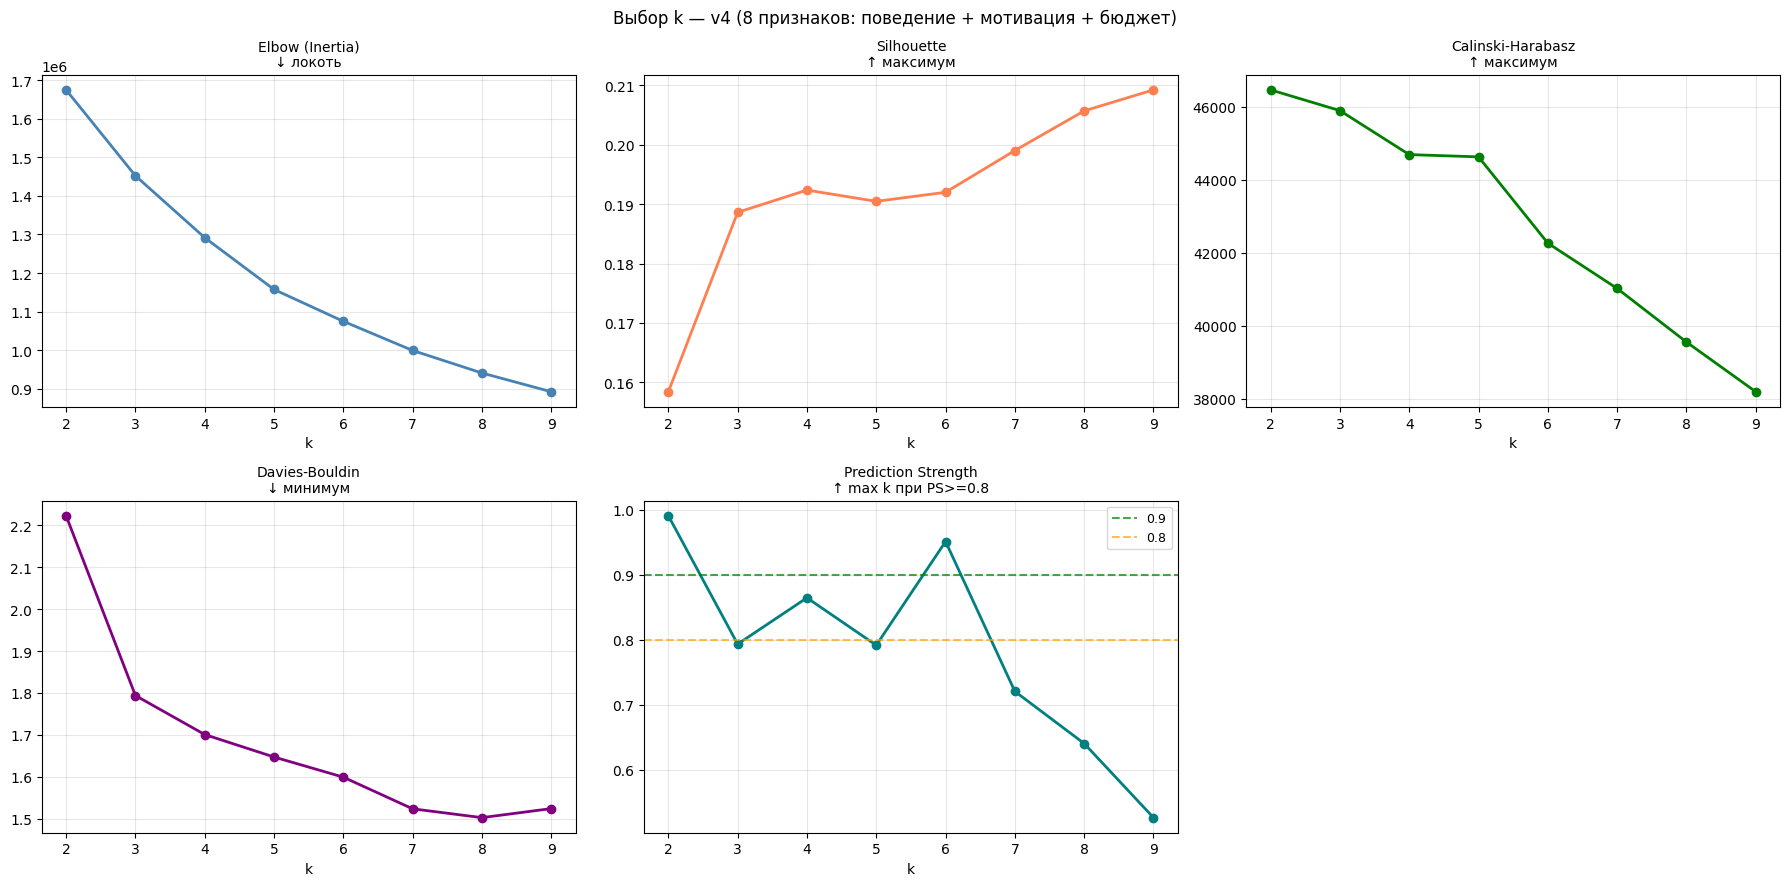

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

data_list = [inertia_v4, silhouette_v4, calinski_v4, davies_v4, ps_values_v4]
titles    = ['Elbow (Inertia)\n\u2193 локоть',
             'Silhouette\n\u2191 максимум',
             'Calinski-Harabasz\n\u2191 максимум',
             'Davies-Bouldin\n\u2193 минимум',
             'Prediction Strength\n\u2191 max k при PS>=0.8']
colors = ['steelblue', 'coral', 'green', 'purple', 'teal']

for ax, vals, title, color in zip(axes, data_list, titles, colors):
    ax.plot(k_list, vals, 'o-', color=color, linewidth=2)
    ax.set_title(title, fontsize=10); ax.set_xlabel('k'); ax.grid(alpha=0.3)

axes[4].axhline(y=0.9, color='green',  linestyle='--', alpha=0.7, label='0.9')
axes[4].axhline(y=0.8, color='orange', linestyle='--', alpha=0.7, label='0.8')
axes[4].legend(fontsize=9)
axes[5].axis('off')
plt.suptitle('Выбор k — v4 (8 признаков: поведение + мотивация + бюджет)', fontsize=12)
plt.tight_layout(); plt.show()


## Шаг 4 — Тест моделей

In [8]:
NUM_COLS = LOG1P_ALREADY + NEEDS_LOG1P + PLAIN_NUM

rng_sil = np.random.RandomState(RANDOM_STATE)
sil_idx = rng_sil.choice(len(X_v4), 50_000, replace=False)

for k in [4, 5, 6]:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20,
                random_state=RANDOM_STATE)
    labels = km.fit_predict(X_v4)
    sil = silhouette_score(X_v4[sil_idx], labels[sil_idx])

    df[f'cluster_k{k}'] = labels

    print(f"\n{'='*60}")
    print(f"  k={k}  |  Silhouette={sil:.4f}")
    print(f"{'='*60}")

    for c in range(k):
        n = (labels == c).sum()
        print(f"  Кластер {c}: {n:,} ({n/len(labels):.1%})")

    profile = df.groupby(f'cluster_k{k}')[NUM_COLS].mean()
    profile_show = profile.copy()
    profile_show['lead_time']  = np.expm1(profile['lead_time']).round(0).astype(int)
    profile_show['prev_stays'] = np.expm1(profile['prev_stays']).round(2)
    profile_show['stay_duration'] = profile['stay_duration'].round(1)
    print(f"\n--- Числовые профили ---")
    print(profile_show.T.to_string())

    print(f"\n--- is_treatment / price_tier / has_children ---")
    for col in ['is_treatment', 'price_tier', 'has_children']:
        print(f"  {col}: {df.groupby(f'cluster_k{k}')[col].mean().round(3).to_dict()}")

    sil_vals = silhouette_samples(X_v4[sil_idx], labels[sil_idx])
    sil_df_k = pd.DataFrame({'sil': sil_vals, 'cluster': labels[sil_idx]})
    print(f"\n--- Silhouette по кластерам ---")
    for c in range(k):
        s = sil_df_k[sil_df_k['cluster'] == c]['sil']
        print(f"  Кластер {c}: mean={s.mean():.3f}  neg={(s<0).mean():.1%}")



  k=4  |  Silhouette=0.1853
  Кластер 0: 71,009 (28.6%)
  Кластер 1: 68,182 (27.4%)
  Кластер 2: 92,817 (37.3%)
  Кластер 3: 16,539 (6.7%)

--- Числовые профили ---
cluster_k4              0          1          2          3
lead_time       32.000000  11.000000  81.000000  71.000000
prev_stays       0.940000   1.010000   0.530000   0.560000
stay_duration    4.600000   2.900000   8.400000  10.800000
guest_age       25.121914  33.255522  37.780083  37.449302
pct_weekend_in   0.285046   0.510948   0.204723   0.219290
price_tier       1.120112   2.481564   2.501417   2.426809

--- is_treatment / price_tier / has_children ---
  is_treatment: {0: 0.0, 1: 0.0, 2: 0.0, 3: 1.0}
  price_tier: {0: 1.12, 1: 2.482, 2: 2.501, 3: 2.427}
  has_children: {0: 0.053, 1: 0.534, 2: 0.531, 3: 0.423}

--- Silhouette по кластерам ---
  Кластер 0: mean=0.247  neg=0.0%
  Кластер 1: mean=0.074  neg=25.4%
  Кластер 2: mean=0.182  neg=4.4%
  Кластер 3: mean=0.397  neg=0.0%

  k=5  |  Silhouette=0.1916
  Кластер 0:

In [9]:
K_FINAL = 6  # <- скорректировать после анализа метрик выше

_km_path = ARTIFACTS_V4 / 'kmeans_v4.joblib'

if FORCE_REFIT or not _km_path.exists():
    km_final = KMeans(
        n_clusters=K_FINAL, init='k-means++',
        n_init=KMEANS_N_INIT_FIN, random_state=RANDOM_STATE
    )
    labels_v4 = km_final.fit_predict(X_v4)
    df['cluster_v4'] = labels_v4

    print(f'k={K_FINAL}: inertia={km_final.inertia_:,.0f}  iter={km_final.n_iter_}')

    counts = pd.Series(labels_v4).value_counts().sort_index()
    for cl, cnt in counts.items():
        pct = cnt / len(labels_v4) * 100
        bar = chr(9608) * int(pct / 2)
        flag = ' <- >40% (проверить различимость)' if pct > 40 else ''
        print(f'  Кластер {cl}: {cnt:>8,} ({pct:5.1f}%)  {bar}{flag}')

    joblib.dump(km_final, _km_path)
    np.save(ARTIFACTS_V4 / 'labels_v4.npy', labels_v4)
    df.to_parquet(ARTIFACTS_V4 / 'df_guests_with_clusters_v4.parquet')
    print('Модель сохранена: artifacts_v4/kmeans_v4.joblib')
else:
    km_final  = joblib.load(_km_path)
    labels_v4 = np.load(ARTIFACTS_V4 / 'labels_v4.npy')
    df['cluster_v4'] = labels_v4
    print(f'Загружено из кэша: kmeans_v4 k={K_FINAL}  (FORCE_REFIT=False)')


k=6: inertia=1,074,644  iter=18
  Кластер 0:   55,455 ( 22.3%)  ███████████
  Кластер 1:   42,148 ( 17.0%)  ████████
  Кластер 2:   47,332 ( 19.0%)  █████████
  Кластер 3:   39,520 ( 15.9%)  ███████
  Кластер 4:   47,555 ( 19.1%)  █████████
  Кластер 5:   16,537 (  6.7%)  ███
Модель сохранена: artifacts_v4/kmeans_v4.joblib


## Шаг 5 — Профили кластеров

In [10]:
print('=' * 70)
print('  ПРОФИЛИ КЛАСТЕРОВ v4')
print('=' * 70)

tier_names = {1: 'Лайт', 2: 'Оптима', 3: 'Ультра'}

for cl in range(K_FINAL):
    mask = labels_v4 == cl
    sub  = df[mask]
    n    = mask.sum()
    pct  = n / len(df) * 100

    sd   = sub['stay_duration'].mean()
    lt   = np.expm1(sub['lead_time'].mean())
    age  = sub['guest_age'].mean()
    ps   = np.expm1(sub['prev_stays'].mean())
    wknd = sub['pct_weekend_in'].mean()
    tier = sub['price_tier'].mean()
    ch   = sub['has_children'].mean()
    trt  = sub['is_treatment'].mean()

    # Сезонность — справочно, не в модели
    s  = sub['pct_summer'].mean()
    a  = sub['pct_autumn'].mean()
    w  = sub['pct_winter'].mean()
    sp = 1 - s - a - w
    dom = max({'лето': s, 'осень': a, 'зима': w, 'весна': sp}, key=lambda x: {'лето': s, 'осень': a, 'зима': w, 'весна': sp}[x])

    print(f'\n+--- Кластер {cl} ({n:,} гостей, {pct:.1f}%) ---')
    print(f'|  Пребывание:    {sd:.1f} ночей')
    print(f'|  Горизонт:      {lt:.0f} дней')
    print(f'|  Возраст:       {age:.1f} лет')
    print(f'|  Лояльность:    {ps:.1f} предыдущих визитов')
    print(f'|  Выходные:      {wknd*100:.1f}% заездов в пятницу/субботу')
    print(f'|  Тир:           {tier:.2f} (1=Лайт, 2=Оптима, 3=Ультра)')
    print(f'|  С детьми:      {ch*100:.1f}%')
    print(f'|  Лечение:       {trt*100:.1f}%')
    print(f'|  [Сезон—справка]: лето={s:.2f} осень={a:.2f} зима={w:.2f} весна={sp:.2f}  -> {dom}')
    print(f'+---')


  ПРОФИЛИ КЛАСТЕРОВ v4

+--- Кластер 0 (55,455 гостей, 22.3%) ---
|  Пребывание:    7.6 ночей
|  Горизонт:      72 дней
|  Возраст:       32.9 лет
|  Лояльность:    0.5 предыдущих визитов
|  Выходные:      21.7% заездов в пятницу/субботу
|  Тир:           2.50 (1=Лайт, 2=Оптима, 3=Ультра)
|  С детьми:      100.0%
|  Лечение:       0.0%
|  [Сезон—справка]: лето=0.52 осень=0.16 зима=0.12 весна=0.21  -> лето
+---

+--- Кластер 1 (42,148 гостей, 17.0%) ---
|  Пребывание:    4.2 ночей
|  Горизонт:      33 дней
|  Возраст:       30.6 лет
|  Лояльность:    0.7 предыдущих визитов
|  Выходные:      99.8% заездов в пятницу/субботу
|  Тир:           1.77 (1=Лайт, 2=Оптима, 3=Ультра)
|  С детьми:      9.7%
|  Лечение:       0.0%
|  [Сезон—справка]: лето=0.25 осень=0.19 зима=0.24 весна=0.32  -> весна
+---

+--- Кластер 2 (47,332 гостей, 19.0%) ---
|  Пребывание:    8.4 ночей
|  Горизонт:      65 дней
|  Возраст:       44.6 лет
|  Лояльность:    0.7 предыдущих визитов
|  Выходные:      7.9% заездов 

Среднее Silhouette: 0.1938
  Кластер 0: mean=0.2196  neg=0.5%  [OK]
  Кластер 1: mean=0.1600  neg=1.5%  [OK]
  Кластер 2: mean=0.1562  neg=8.3%  [OK]
  Кластер 3: mean=0.0453  neg=36.8%  [WARN]
  Кластер 4: mean=0.2914  neg=0.0%  [OK]
  Кластер 5: mean=0.3742  neg=0.0%  [OK]


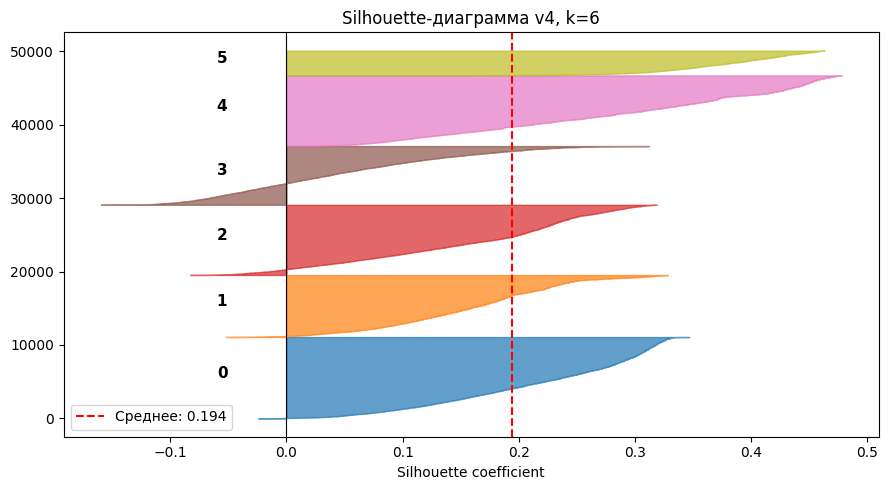

In [11]:
rng_s = np.random.RandomState(RANDOM_STATE)
idx_s = rng_s.choice(len(X_v4), SILHOUETTE_SAMPLE, replace=False)
sil_samples = silhouette_samples(X_v4[idx_s], labels_v4[idx_s])
avg_sil = sil_samples.mean()

print(f'Среднее Silhouette: {avg_sil:.4f}')
for cl in range(K_FINAL):
    mask = labels_v4[idx_s] == cl
    vals = sil_samples[mask]
    neg  = (vals < 0).mean() * 100
    flag = 'OK' if vals.mean() > 0.15 and neg < 10 else 'WARN'
    print(f'  Кластер {cl}: mean={vals.mean():.4f}  neg={neg:.1f}%  [{flag}]')

fig, ax = plt.subplots(figsize=(9, 5))
y_lower = 10
cmap = plt.cm.tab10
for i in range(K_FINAL):
    cluster_sil = np.sort(sil_samples[labels_v4[idx_s] == i])
    y_upper = y_lower + len(cluster_sil)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     alpha=0.7, color=cmap(i / K_FINAL))
    ax.text(-0.06, y_lower + 0.5 * len(cluster_sil),
            str(i), fontweight='bold', fontsize=11)
    y_lower = y_upper + 10
ax.axvline(x=avg_sil, color='red', linestyle='--', label=f'Среднее: {avg_sil:.3f}')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Silhouette coefficient')
ax.set_title(f'Silhouette-диаграмма v4, k={K_FINAL}')
ax.legend(); plt.tight_layout(); plt.show()


In [12]:
n_total = len(df)
f_ratios = []
for col in ALL_FEATURES:
    groups = [df.loc[labels_v4 == i, col].dropna() for i in range(K_FINAL)]
    gm = df[col].mean()
    bv = sum(len(g) * (g.mean() - gm) ** 2 for g in groups) / (K_FINAL - 1)
    wv = sum(((g - g.mean()) ** 2).sum() for g in groups) / (n_total - K_FINAL)
    f_ratios.append((col, bv / wv if wv > 0 else 0))
f_ratios.sort(key=lambda x: -x[1])
print('F-ratio признаков (различающая сила):')
for feat, fr in f_ratios:
    bar = chr(9608) * min(int(fr / 5000), 30)
    print(f'  {feat:<28}  F={fr:>10,.0f}  {bar}')
print('\n(Ожидаем is_treatment и price_tier в топе — иначе пересмотреть)')


F-ratio признаков (различающая сила):
  is_treatment                  F=255,789,922  ██████████████████████████████
  has_children                  F=   117,185  ███████████████████████
  pct_weekend_in                F=    56,985  ███████████
  lead_time                     F=    35,748  ███████
  price_tier                    F=    29,585  █████
  stay_duration                 F=    26,133  █████
  guest_age                     F=    11,271  ██
  prev_stays                    F=     2,999  

(Ожидаем is_treatment и price_tier в топе — иначе пересмотреть)


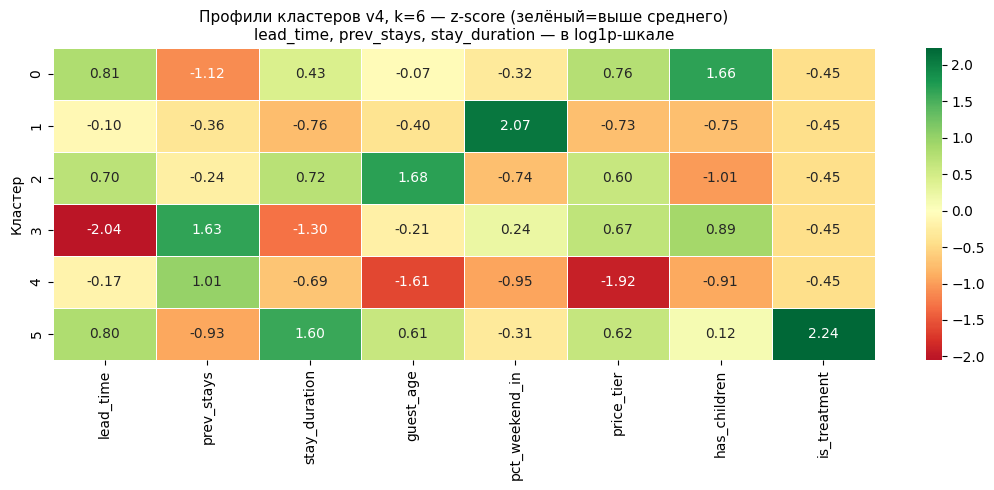

In [13]:
profile = df.groupby('cluster_v4')[ALL_FEATURES].mean()
profile_z = pd.DataFrame(
    StandardScaler().fit_transform(profile),
    index=profile.index, columns=profile.columns
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(profile_z, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 10})
ax.set_title(
    f'Профили кластеров v4, k={K_FINAL} — z-score (зелёный=выше среднего)\n'
    'lead_time, prev_stays, stay_duration — в log1p-шкале', fontsize=11
)
ax.set_ylabel('Кластер')
plt.tight_layout(); plt.show()


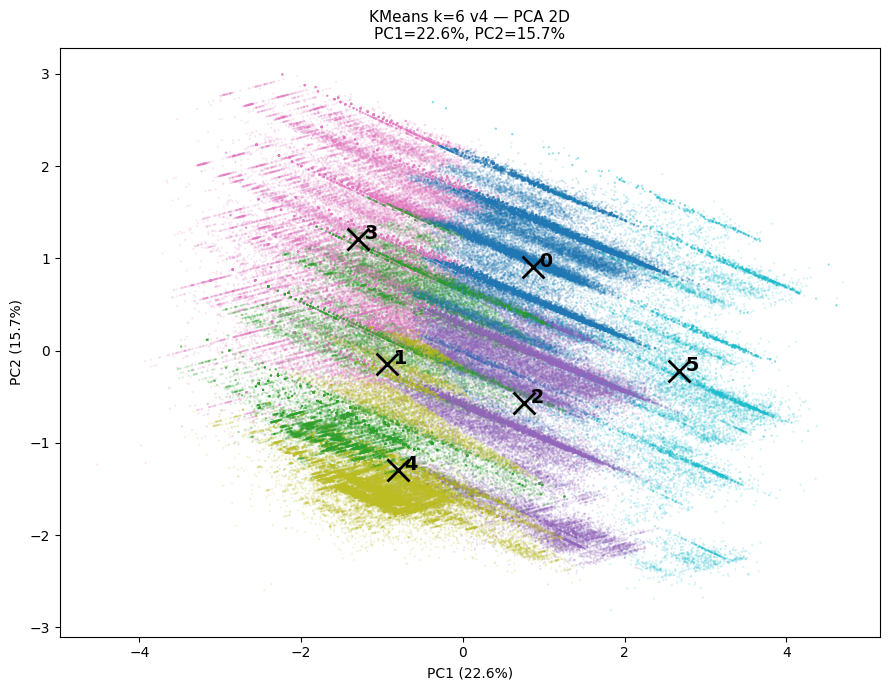

In [14]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X_v4)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X_2d[:, 0], X_2d[:, 1],
           c=labels_v4, cmap='tab10', s=0.4, alpha=0.15)
centroids_2d = pca.transform(km_final.cluster_centers_)
for i, (cx, cy) in enumerate(centroids_2d):
    ax.scatter(cx, cy, s=250, c='black', marker='x', linewidths=2, zorder=5)
    ax.annotate(f' {i}', (cx, cy), fontsize=14, fontweight='bold', zorder=6)
ax.set_title(
    f'KMeans k={K_FINAL} v4 — PCA 2D\n'
    f'PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}',
    fontsize=11
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.tight_layout(); plt.show()


## Шаг 6 — Проверка независимости + матрица аффинности

In [15]:
print('tariff_group по кластерам (не входил в модель):')
ct = pd.crosstab(df['cluster_v4'], df['tariff_group'], normalize='index').round(3)
print(ct.to_string())

print('\ngender по кластерам (не входил в модель):')
print(pd.crosstab(df['cluster_v4'], df['gender'], normalize='index').round(3).to_string())

ari_tariff = adjusted_rand_score(
    pd.Categorical(df['tariff_group']).codes, labels_v4)
print(f'\nARI(cluster_v4, tariff_group) = {ari_tariff:.4f}')
print(f'  v1 = 0.8827  v3 = 0.178')
verdict = 'независимость сохранена' if ari_tariff < 0.3 else 'WARN: умеренная связь с тарифом'
print(f'  v4 = {ari_tariff:.4f} ({verdict})')

# ── Матрица аффинности cluster × season ───────────────────────────────────
# Отвечает: какой кластер таргетировать при прогнозируемом дефиците в сезон X?
print('\n--- Матрица аффинности cluster x season ---')
season_cols = ['pct_summer', 'pct_autumn', 'pct_winter']
aff = df.groupby('cluster_v4')[season_cols].mean().round(3)
aff['pct_spring'] = (1 - aff[season_cols].sum(axis=1)).round(3)
aff.columns = ['лето', 'осень', 'зима', 'весна']
print(aff.to_string())
print('\nПример: Prophet предсказал дефицит в июле → таргетируем кластер с max(лето)')


tariff_group по кластерам (не входил в модель):
tariff_group  other  акция/спецпредл  лечебный  льготный/корп  новогодний/банкет  событие/группы  социальный  стандарт/оптима  ультра/all-incl
cluster_v4                                                                                                                                    
0             0.007            0.000      0.00          0.001              0.026           0.003       0.007            0.199            0.756
1             0.124            0.031      0.00          0.001              0.042           0.160       0.055            0.233            0.354
2             0.085            0.001      0.00          0.001              0.008           0.016       0.038            0.181            0.670
3             0.011            0.001      0.00          0.000              0.031           0.012       0.002            0.346            0.596
4             0.140            0.029      0.00          0.003              0.068           0.3

In [16]:
print('Артефакты в artifacts_v4/:')
for f in sorted(ARTIFACTS_V4.iterdir()):
    if f.is_file():
        print(f'  {f.name:<45} {f.stat().st_size / 1024:>8.1f} KB')


Артефакты в artifacts_v4/:
  df_guests_with_clusters_v4.parquet              4116.1 KB
  feature_meta_v4.joblib                             0.3 KB
  kmeans_v4.joblib                                 971.8 KB
  labels_v4.npy                                    971.0 KB
  preprocessor_v4.joblib                             4.4 KB
  X_scaled_v4.npy                                 7767.2 KB


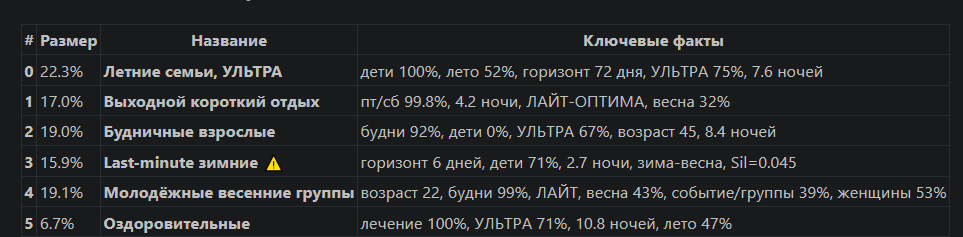

Сегмент 0 — «Летние семьи, УЛЬТРА» (55 455 гостей, 22.3%)
Демография и состав
Самый крупный сегмент санатория. Средний возраст — 32.9 года, что типично для родителей дошкольников и детей младшей школы. Гендерный состав: мужчины 41.4%, женщины 30.3% (28.3% пол неизвестен). Дети присутствуют в 100% случаев — это единственный кластер с абсолютным семейным составом, без исключений.

Поведение при бронировании
Горизонт планирования — 72 дня (≈2.5 месяца). Это «плановые» туристы: они знают, что поедут летом, и бронируют заранее весной. Вероятно, привязаны к школьным каникулам и отпускному графику. Лояльность низкая (0.5 предыдущих визитов) — большинство приезжает впервые или редко повторяет, что объясняется дороговизной и сравнением предложений между санаториями.

Потребительский профиль
Ценовой тир 2.50 — фактически УЛЬТРА. Распределение тарифов подтверждает: УЛЬТРА/all-inclusive занимает 75.6% кластера, стандарт/оптима — только 19.9%. Гости покупают максимальный пакет: питание по системе «всё включено», максимальный номерной фонд, детская инфраструктура (аквапарк, анимация). Длина пребывания 7.6 ночей — типичная семейная неделя.

Сезонность
Лето доминирует (52%), но кластер присутствует и весной (21%) — часть семей приезжает на майские праздники. Заезды в пятницу/субботу — только 21.7%, то есть большинство приезжает в будни, подстраиваясь под начало/конец каникул, а не под выходные.

Маркетинговая логика

Канал: семейные агрегаторы (Туту, Ostrovok), Instagram/ВКонтакте с семейным контентом
Оффер: early bird за 2-3 месяца до лета («Лето 2025 — бронируй сейчас, скидка 10%»)
Аквапарк как якорный аргумент: для этого сегмента он критически важен
Upsell: услуги для детей, детское меню, специальные программы
Сегмент 1 — «Выходной отдых» (42 148 гостей, 17.0%)
Демография и состав
Молодые гости 30.6 лет, преимущественно без детей (только 9.7%). Женщин больше, чем мужчин: 39.1% vs 34.4%. Вероятно, пары или группы друзей. Лояльность 0.7 — слегка выше первичного посещения, часть возвращается.

Поведение при бронировании
Заезды в пятницу или субботу — 99.8%. Это абсолютный отличительный признак кластера: гости приезжают строго на выходные, уезжают в воскресенье или понедельник. Горизонт 33 дня — бронируют примерно за месяц, не экстренно, но и не сильно заранее. Пребывание 4.2 ночи (типичный формат: пятница вечер — вторник утро или пятница — воскресенье).

Потребительский профиль
Тир 1.77 — между ЛАЙТ и ОПТИМА. Тарифы: УЛЬТРА 35.4%, стандарт/оптима 23.3%, событие/группы 16%, социальный 5.5%. Присутствие «событие/группы» 16% указывает на корпоративные выезды или организованные группы выходного дня (девичники, тимбилдинги). Не самый дорогой сегмент, но платит за удобство и сервис.

Сезонность
Равномерное распределение по сезонам: весна 32%, зима 24%, лето 25%, осень 19%. Единственный кластер, который не привязан к летнему сезону — актуален круглый год. Для санатория это стратегически важный сегмент для заполнения в межсезонье.

Маркетинговая логика

Канал: геотаргетинг в регионе (гости из ближайших городов), Telegram-каналы про отдых
Оффер: «Выходные пакеты» — пятница+суббота+воскресенье с фиксированной ценой
Аквапарк + spa как центральный аттракцион для вечернего отдыха
Таргетинг: за 3-4 недели до выходных, особенно длинные праздники
Сегмент 2 — «Будничные взрослые» (47 332 гостя, 19.0%)
Демография и состав
Самый взрослый кластер: средний возраст 44.6 года. Мужчин больше (45.7% vs 35.8%). Детей — практически ноль (0.1%). Это люди, путешествующие без семьи: деловые поездки, отдых вдвоём, индивидуальный отпуск. Лояльность 0.7 — похожа на кластер 1, большинство не постоянные клиенты.

Поведение при бронировании
Заезды в пятницу/субботу — только 7.9% — практически никогда не приезжают на выходные. Приезжают строго в будни: понедельник—четверг. Горизонт 65 дней — планируют заранее, чуть меньше чем семьи (кластер 0). Пребывание 8.4 ночи — одно из самых длинных среди не-лечебных кластеров, примерно полторы недели.

Потребительский профиль
Тир 2.42 — ОПТИМА/УЛЬТРА. УЛЬТРА занимает 67% кластера, стандарт/оптима — 18.1%. Покупают качество: хороший номер, питание, возможно частичные оздоровительные процедуры (но не лечебный тариф). Отдыхают обстоятельно, без спешки, в будни когда санаторий менее загружен.

Сезонность
Лето (37%) и осень (27%) доминируют. Зима минимальна (13%). Это осознанный выбор: взрослые гости без детей могут позволить себе не лето, выбирают комфортную погоду.

Маркетинговая логика

Стратегически ценен для заполнения будней: пока семьи занимают выходные, этот кластер обеспечивает недельную загрузку
Канал: email-рассылки, контекстная реклама по запросам «отдых без детей», «тихий отпуск»
Оффер: «Будничные тарифы» со скидкой vs выходные, пакеты 7-10 ночей
Не нужна детская инфраструктура — акцент на тишину, процедуры, бассейн
Сегмент 3 — «Last-minute зимние семьи» ⚠️ (39 520 гостей, 15.9%)
Важная оговорка: Silhouette=0.045, 36.8% гостей имеют отрицательное значение. Кластер статистически слабый — границы размыты с кластером 0 (плановые семьи). Интерпретировать с осторожностью: часть гостей «случайно» попала сюда из других кластеров.

Демография и состав
Возраст 31.9 лет — самые молодые среди семейных гостей. Дети в 71.1% случаев — значимое, но не абсолютное семейное присутствие (в отличие от кластера 0 с 100%). Мужчин 48.2%, женщин 36.3%. Лояльность 1.2 — самая высокая в модели. Это постоянные клиенты, которые возвращаются.

Поведение при бронировании
Горизонт бронирования — 6 дней. Это «импульсивные» гости: решение принимается за неделю до поездки. Психологически это не безответственность, а другой паттерн жизни: не привязаны к жёсткому графику, или реагируют на внезапно появившееся свободное время. Высокая лояльность + short lead time = постоянные клиенты, которые хорошо знают санаторий и не боятся бронировать в последний момент. Пребывание 2.7 ночи — короткие визиты, скорее «выбраться на пару дней», чем полноценный отпуск.

Потребительский профиль
Тир 2.45 — ОПТИМА/УЛЬТРА. УЛЬТРА 59.6%, стандарт/оптима 34.6%. Несмотря на импульсивность, платят хорошо. Заезды в пятницу/субботу — 39.9%, то есть значительная часть приезжает на выходные, но не доминирующая.

Сезонность
Зима (33%) и весна (32%) — кластер противоположен летним семьям. Новый год, февральские праздники, март. Вероятно, это и есть основной «новогодний/каникулярный» поток, который бронирует за несколько дней до даты.

Маркетинговая логика

Push-уведомления и мессенджеры за 3-7 дней («Свободные места на эти выходные — 15% скидка»)
Ретаргетинг по тем, кто уже был (высокая лояльность)
Зимние акции: Новый год, 23 февраля, 8 марта с коротким горизонтом
Не нужен прогрев за месяц — срочность работает лучше
Сегмент 4 — «Молодёжные весенние группы, ЛАЙТ» (47 555 гостей, 19.1%)
Демография и состав
Самый молодой кластер: 22.5 года в среднем. Преимущественно женщины — 52.7% (мужчин только 25.7%, остальные пол неизвестен). Детей почти нет (3.7%). Силуэт 0.2914 с 0% отрицательных — второй по чёткости кластер после лечебного. Лояльность 1.0 — возвращаются.

Поведение при бронировании
Заезды в пятницу/субботу — 0.9%. Приезжают исключительно в будни. В сочетании с молодым возрастом это сильный сигнал организованных групповых поездок: студенческие туры, школьные поездки, спортивные лагеря, корпоративные тимбилдинги молодёжных компаний. Горизонт 31 день — бронируют за месяц (организатор планирует поездку группы). Пребывание 4.4 ночи.

Потребительский профиль
Тир 1.19 — почти чистый ЛАЙТ. Тарифы: событие/группы 39%, стандарт/оптима 17%, other 14%, УЛЬТРА 12.9%, социальный 7.3%. Совокупность «событие/группы» + «социальный» + молодой возраст + будни + женщины = организованные групповые визиты по корпоративным или льготным ценам (профсоюзные путёвки, спортивные федерации, студенческие союзы).

Сезонность
Весна доминирует (43%). Это объясняет паттерн: школьные и студенческие группы ездят весной (апрель-май), летом они разъезжаются по индивидуальным отпускам.

Маркетинговая логика

B2B канал: работа с университетами, школами, профсоюзами, спортивными организациями
Групповые тарифы с расчётом на 10-50+ человек
Аквапарк как ключевое преимущество для молодой аудитории
Весенние предложения: апрель-май, будни, групповой формат
Для рекомендатора: если прогноз даёт дефицит в будни весной → этот сегмент
Сегмент 5 — «Оздоровительные» (16 537 гостей, 6.7%)
Демография и состав
Самый маленький, но при этом самый чёткий сегмент: Silhouette=0.3742, 0% отрицательных значений. Возраст 37.4 года. Мужчин 47.1%, женщин 34.5%. Дети присутствуют в 42.3% визитов — лечебные программы выбирают и семьи с детьми, не только одиночки. Лояльность 0.6 — чуть ниже среднего; возможно, это специфический тип поездки, которая не повторяется ежегодно.

Поведение при бронировании
Горизонт 71 день — планируют почти так же заранее, как плановые семьи. Лечение требует подготовки: нужно оформить направление, согласовать сроки, подготовиться. Пребывание 10.8 ночей — самое длинное среди всех кластеров, стандартный санаторно-курортный курс (10-14 дней). Заезды в пятницу/субботу — 21.9%, без выраженного паттерна.

Потребительский профиль
Тир 2.43 — ОПТИМА/УЛЬТРА. Тарифы: УЛЬТРА 71.3%, лечебный (отдельная категория) 12%, стандарт/оптима 16.1%. Покупают программы «УЛЬТРА С ЛЕЧЕНИЕМ» и «ОПТИМА С ЛЕЧЕНИЕМ» — это коммерческие гости, сами выбравшие и оплатившие оздоровительный пакет. (ФСС и корпоративные путёвки отфильтрованы в pipeline.)

Сезонность
Лето (47%) и осень (28%) — люди предпочитают проходить лечение в тёплое время. Зима критически мала — только 6%. Это важно для прогноза: зимой санаторий теряет этот сегмент почти полностью.

F-ratio предупреждение
is_treatment дал F=255 789 922 — в 2000 раз выше следующего признака. Это означает, что кластер 5 является жёстко изолированным: модель сначала отделила лечебных гостей, затем разбила остальных на 5 групп. Для бизнеса это правильно — лечебные гости принципиально отличаются от отдыхающих по мотивации и потребностям.

Маркетинговая логика

Канал: медицинские агрегаторы (Санатории.ру, Здравкурорт), рекомендации врачей
Оффер: оздоровительные программы с конкретными показаниями (позвоночник, суставы, нервная система)
Лето/осень — основное окно активности
При зимнем дефиците этот сегмент не поможет — нужны другие кластеры